# Master Thesis Metrics Analysis - *100% AI Generated*

A narrative analysis of how thesis structure and writing style vary across departments and publication years.

## 1) Executive Summary

This notebook analyzes `master_thesis_metrics_analysis_v2.csv` to uncover cross-department differences in thesis size and structure.

Primary questions:
- How much of each thesis is core content versus non-core pages (appendix/references)?
- How has thesis length changed over time?
- Which departments are more verbose in body text and abstract style?
- Which metrics move together and which appear independent?

In [11]:
# Core imports and display setup
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="talk")

In [12]:
# Locate project root and inspect baseline analysis artifacts
def locate_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "pyproject.toml").exists() or (candidate / "README.md").exists():
            return candidate
    return start

project_root = locate_project_root(Path.cwd())
print(f"Project root: {project_root}")

artifact_patterns = ["**/*.ipynb", "**/*.py", "**/*.png", "**/*.jpg", "**/*.jpeg", "**/*.svg"]
artifact_paths = []
for pattern in artifact_patterns:
    artifact_paths.extend(project_root.glob(pattern))

artifact_df = pd.DataFrame({"path": [str(p.relative_to(project_root)) for p in artifact_paths]}).drop_duplicates()
exclude_prefixes = (".venv/", "venv/", "__pycache__/", ".git/")
artifact_df = artifact_df[~artifact_df["path"].str.startswith(exclude_prefixes)]
artifact_df = artifact_df.assign(ext=artifact_df["path"].str.rsplit(".", n=1).str[-1].str.lower())

baseline_focus = artifact_df[artifact_df["path"].str.contains("exploring_data|exstraction_more_from_pdf|metrics", case=False, regex=True)]
print("Baseline analysis artifacts (sample):")
display(baseline_focus.sort_values("path").head(20))

print("Artifact counts by extension (excluding environment/cache files):")
display(artifact_df["ext"].value_counts().rename_axis("extension").to_frame("count"))

Project root: /Users/oliver/Desktop/MSc_Speciale/Thesis_OCR
Baseline analysis artifacts (sample):


,path,ext
1,exploring_data/Cleaning_Orbit_Meta.ipynb,ipynb
0,exploring_data/SANDBOX_Exploring_track1.ipynb,ipynb
6,exstraction_more_from_pdf/ARCHIVES/STOP_exsten...,ipynb
4,exstraction_more_from_pdf/ARCHIVES/metrics_fro...,ipynb
7,exstraction_more_from_pdf/ARCHIVES/seasonality...,ipynb
5,exstraction_more_from_pdf/ARCHIVES/seasonality...,ipynb
8,exstraction_more_from_pdf/ARCHIVES/thesis_exst...,ipynb
12,exstraction_more_from_pdf/gcp_metrics_from_pdf...,py
13,exstraction_more_from_pdf/gcp_seasonality_from...,py
14,exstraction_more_from_pdf/local_metrics_from_p...,py


Artifact counts by extension (excluding environment/cache files):


,count
extension,
py,15
ipynb,8


### Baseline to Advanced Evolution

The existing workspace already includes extraction notebooks and processing scripts. This notebook intentionally moves beyond basic summaries by adding:
- Robust join validation checks on thesis identifiers.
- Distribution-aware visuals (box/violin-style comparisons).
- Temporal median trends by department instead of single global averages.
- Correlation structure and anomaly inspection for deeper interpretation.

In [13]:
# Load data from the requested source name with robust fallbacks
candidate_paths = [
    project_root / "master_thesis_metrics_analysis_v2.csv",
    project_root / "Data/gcp_order/dtu_findit/extraction_and_processing/master_thesis_metrics_analysis_v2.csv",
    project_root / "Data/master_thesis_metrics_analysis_v2.csv",
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    discovered = list(project_root.glob("**/master_thesis_metrics_analysis_v2.csv"))
    if not discovered:
        raise FileNotFoundError("Could not find master_thesis_metrics_analysis_v2.csv in the project.")
    data_path = discovered[0]

df = pd.read_csv(data_path, sep=";", encoding="utf-8")
print(f"Loaded: {data_path}")
print(f"Shape: {df.shape}")
display(df.head())

Loaded: /Users/oliver/Desktop/MSc_Speciale/Thesis_OCR/Data/gcp_order/dtu_findit/extraction_and_processing/master_thesis_metrics_analysis_v2.csv
Shape: (4254, 15)


,pdf_file,member_id_ss_metrics,num_tot_pages,num_cont_pages,match_trigger,num_words_full,num_words_cont,abstract_ts,Author,Publication Year,primary_member_id_s,Title,Department_new,author_count,handin_month
0,5ce67fe9d9001d016b4fccc7_Experimental analysis...,5ce67fe9d9001d016b4fccc7,66,62,exact ('references'),15415,13882,Department of Chemical and Biochemical Enginee...,"Joshi, Ameya Sunil",2019,5ce67fe9d9001d016b4fccc7,Experimental analysis of CO2 vapour liquid equ...,DTU Chemical Engineering,1,April 2019
1,5c7a72ffd9001d361b4cd3ec_Heart segmentation us...,5c7a72ffd9001d361b4cd3ec,84,74,"prefix-match ('appendix a', prefix='appendix')",19892,18374,"In the ﬁeld of medical imaging, a lot of resea...","Ellegaard, Andreas Høyby",2019,5c7a72ffd9001d361b4cd3ec,Heart segmentation using deep learning|Segment...,DTU Compute,1,January 2019
2,5cee68eed9001d2064299318_Deep Reinforcement Le...,5cee68eed9001d2064299318,61,51,exact ('references'),20540,17924,Robotic exploration in an unknown environment ...,"Hamilton, Francis Nils",2019,5cee68eed9001d2064299318,Deep Reinforcement Learning: Applying an actor...,DTU Electro,1,April 2019
3,5cf10bded9001d206429933c_Restoration of marine...,5cf10bded9001d206429933c,29,24,exact ('references'),9603,7793,Anthropogenic impacts on marine habitats are a...,"Nordfoss, Pauli Holm",2019,5cf10bded9001d206429933c,Restoration of marine boulder reefs: addressin...,DTU Aqua,1,May 2019
4,5cf10bded9001d206429933f_Data augmentation of ...,5cf10bded9001d206429933f,74,72,exact ('bibliography'),10694,10338,This thesis is about a deep learning segmentat...,"Talleruphuus, Anne Sofie",2019,5cf10bded9001d206429933f,Data augmentation of CT scans|Data augmentatio...,DTU Compute,1,May 2019


In [14]:
# 2) Data cleaning and join logic checks
required_cols = [
    "member_id_ss_metrics", "primary_member_id_s", "Department_new", "Publication Year",
    "num_tot_pages", "num_cont_pages", "num_words_cont", "num_words_full", "abstract_ts"
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing expected columns: {missing_cols}")

for col in ["num_tot_pages", "num_cont_pages", "num_words_cont", "num_words_full"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Publication Year"] = pd.to_numeric(df["Publication Year"], errors="coerce")
df["Publication Year"] = df["Publication Year"].round().astype("Int64")
df["Department_new"] = df["Department_new"].astype("string").str.strip()

df["id_match"] = df["member_id_ss_metrics"].astype("string") == df["primary_member_id_s"].astype("string")
df["abstract_word_count"] = df["abstract_ts"].astype("string").str.split().str.len()

quality_summary = pd.DataFrame({
    "metric": [
        "rows_total",
        "id_mismatch_rows",
        "missing_department_rows",
        "missing_publication_year_rows",
        "rows_with_nonpositive_total_pages",
    ],
    "value": [
        len(df),
        (~df["id_match"]).sum(),
        df["Department_new"].isna().sum() + (df["Department_new"] == "").sum(),
        df["Publication Year"].isna().sum(),
        (df["num_tot_pages"] <= 0).sum(),
    ],
})
display(quality_summary)

analysis_df = df.copy()
analysis_df = analysis_df[analysis_df["id_match"]]
analysis_df = analysis_df.dropna(subset=["Department_new", "Publication Year", "num_tot_pages", "num_cont_pages", "num_words_cont"])
analysis_df = analysis_df[analysis_df["num_tot_pages"] > 0].copy()

analysis_df["content_ratio"] = (analysis_df["num_cont_pages"] / analysis_df["num_tot_pages"]).clip(lower=0, upper=1)
analysis_df["filler_share"] = (1 - analysis_df["content_ratio"]).clip(lower=0, upper=1)

print(f"Analysis-ready rows: {len(analysis_df):,}")

,metric,value
0,rows_total,4254
1,id_mismatch_rows,0
2,missing_department_rows,0
3,missing_publication_year_rows,0
4,rows_with_nonpositive_total_pages,0


Analysis-ready rows: 4,254


### Cleaning Insight

Join consistency is explicitly validated via `member_id_ss_metrics == primary_member_id_s`. Rows with missing department/year or invalid total page count are excluded from analytical modules to avoid biased department and temporal comparisons.

## 2.5) Preliminary Descriptive Landscape

Before the deeper ratio/correlation modules, these baseline visuals summarize dataset composition by department, collaboration pattern, and yearly thesis volume.

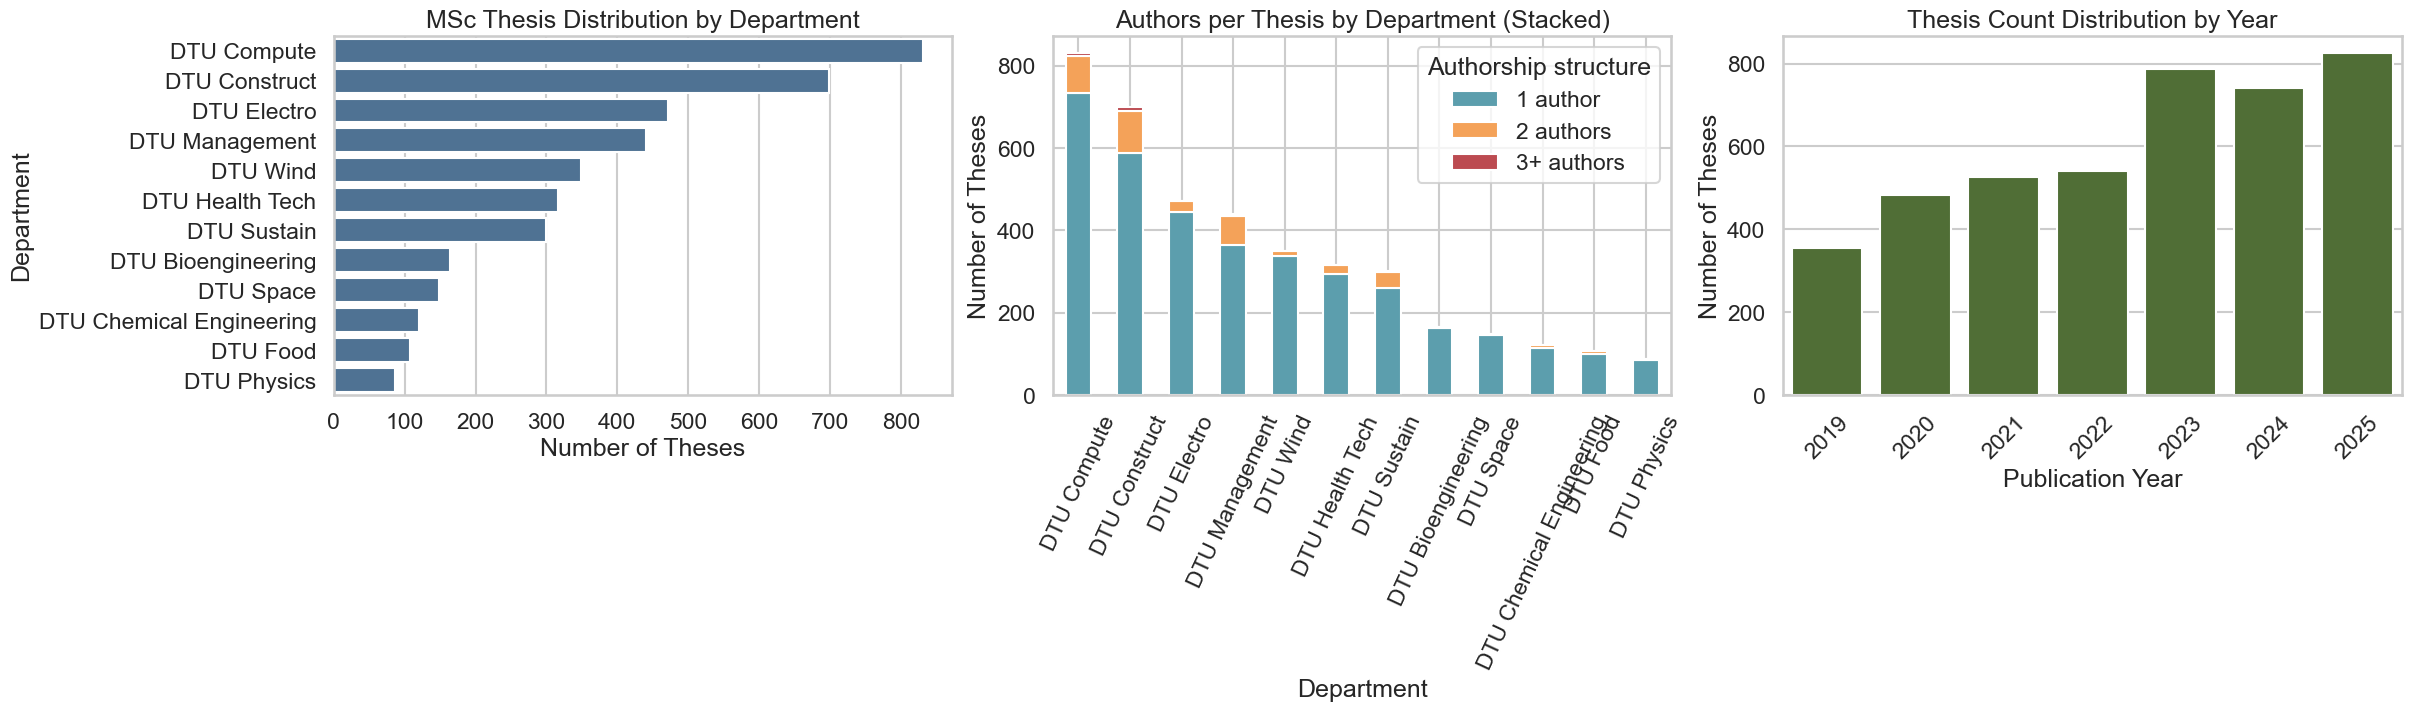

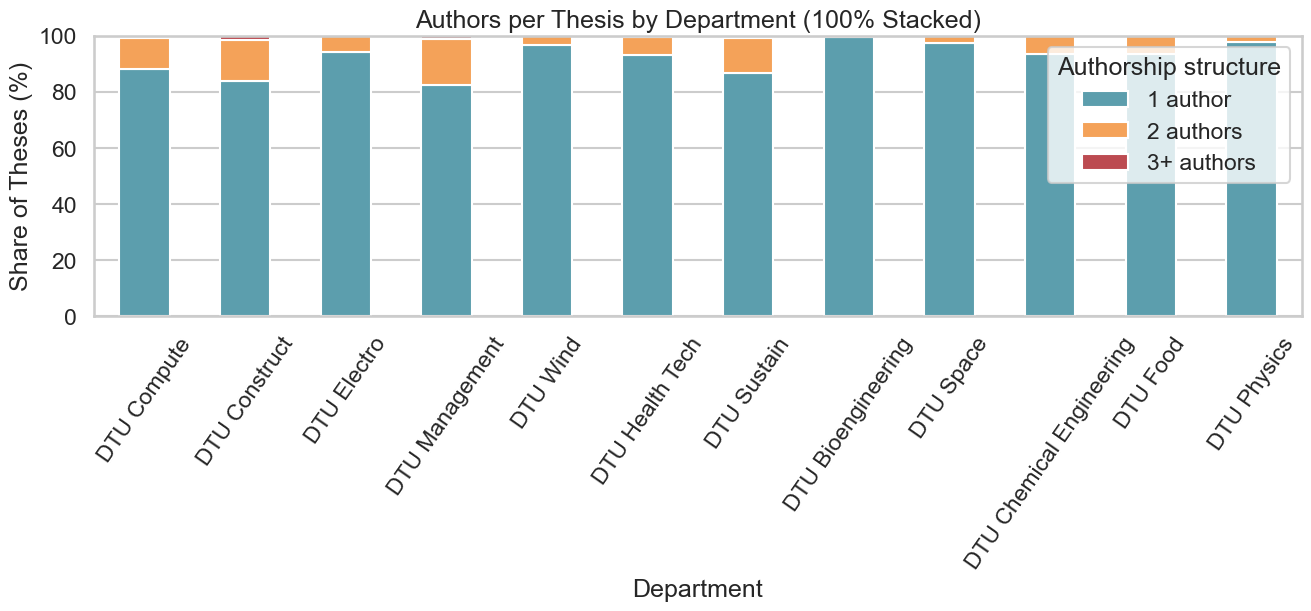

In [15]:
# Preliminary descriptive plots: faculty distribution, authors-per-thesis mix, and yearly thesis volume
import re

def count_authors(author_text):
    if pd.isna(author_text):
        return np.nan
    text = str(author_text).strip()
    if not text:
        return np.nan

    # Common separators for multiple authors in metadata exports
    separators = ["|", ";", " and ", " & ", " + "]
    for sep in separators:
        if sep in text:
            parts = [p.strip() for p in text.split(sep) if p.strip()]
            return max(len(parts), 1)

    # Fallback: if there are multiple comma-separated full names, estimate pairs
    comma_parts = [p.strip() for p in text.split(",") if p.strip()]
    if len(comma_parts) >= 4 and len(comma_parts) % 2 == 0:
        return len(comma_parts) // 2

    return 1

desc_df = analysis_df.copy()
desc_df["author_count"] = desc_df["Author"].apply(count_authors)
desc_df["author_count"] = desc_df["author_count"].fillna(1).astype(int)
desc_df["author_group"] = desc_df["author_count"].clip(upper=3).map({1: "1 author", 2: "2 authors", 3: "3+ authors"})

# 1) Department/faculty distribution of MSc theses
dept_distribution = desc_df["Department_new"].value_counts().head(12).rename_axis("Department_new").reset_index(name="thesis_count")

# 2) Stacked bar: number of authors per thesis per department
author_mix = (
    desc_df[desc_df["Department_new"].isin(dept_distribution["Department_new"])]
    .groupby(["Department_new", "author_group"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["1 author", "2 authors", "3+ authors"], fill_value=0)
    .loc[dept_distribution["Department_new"]]
    .sort_values("1 author", ascending=False)
)

# Percentage-normalized collaboration mix for fair cross-department comparison
author_mix_pct = author_mix.div(author_mix.sum(axis=1), axis=0).mul(100)

# 3) Distribution of theses per year
year_distribution = (
    desc_df["Publication Year"]
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis("Publication Year")
    .reset_index(name="thesis_count")
)

fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)

sns.barplot(data=dept_distribution, y="Department_new", x="thesis_count", ax=axes[0], color="#44739e")
axes[0].set_title("MSc Thesis Distribution by Department")
axes[0].set_xlabel("Number of Theses")
axes[0].set_ylabel("Department")

author_mix.plot(kind="bar", stacked=True, ax=axes[1], color=["#5c9ead", "#f4a259", "#bc4b51"])
axes[1].set_title("Authors per Thesis by Department (Stacked)")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Number of Theses")
axes[1].tick_params(axis="x", rotation=65)
axes[1].legend(title="Authorship structure", loc="upper right")

sns.barplot(data=year_distribution, x="Publication Year", y="thesis_count", ax=axes[2], color="#4f772d")
axes[2].set_title("Thesis Count Distribution by Year")
axes[2].set_xlabel("Publication Year")
axes[2].set_ylabel("Number of Theses")
axes[2].tick_params(axis="x", rotation=45)

plt.show()

# Additional view: normalized stacked barplot (100%)
fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
author_mix_pct.plot(kind="bar", stacked=True, ax=ax, color=["#5c9ead", "#f4a259", "#bc4b51"])
ax.set_title("Authors per Thesis by Department (100% Stacked)")
ax.set_xlabel("Department")
ax.set_ylabel("Share of Theses (%)")
ax.tick_params(axis="x", rotation=55)
ax.set_ylim(0, 100)
ax.legend(title="Authorship structure", loc="upper right")
plt.show()

#display(dept_distribution.head(12))
#display(author_mix.head(12))
#display(author_mix_pct.round(2).head(12))
#display(year_distribution)

### Narrative Insight: Descriptive Baseline

The department distribution reveals where thesis production is concentrated, while the stacked authorship bars show whether collaboration practices differ by discipline.

The new **100% stacked version** removes department-size effects and highlights collaboration intensity directly as proportions. This makes it easier to compare departments with very different thesis volumes. The yearly distribution contextualizes later trend analyses by showing whether observed time effects may partly reflect changing cohort sizes.

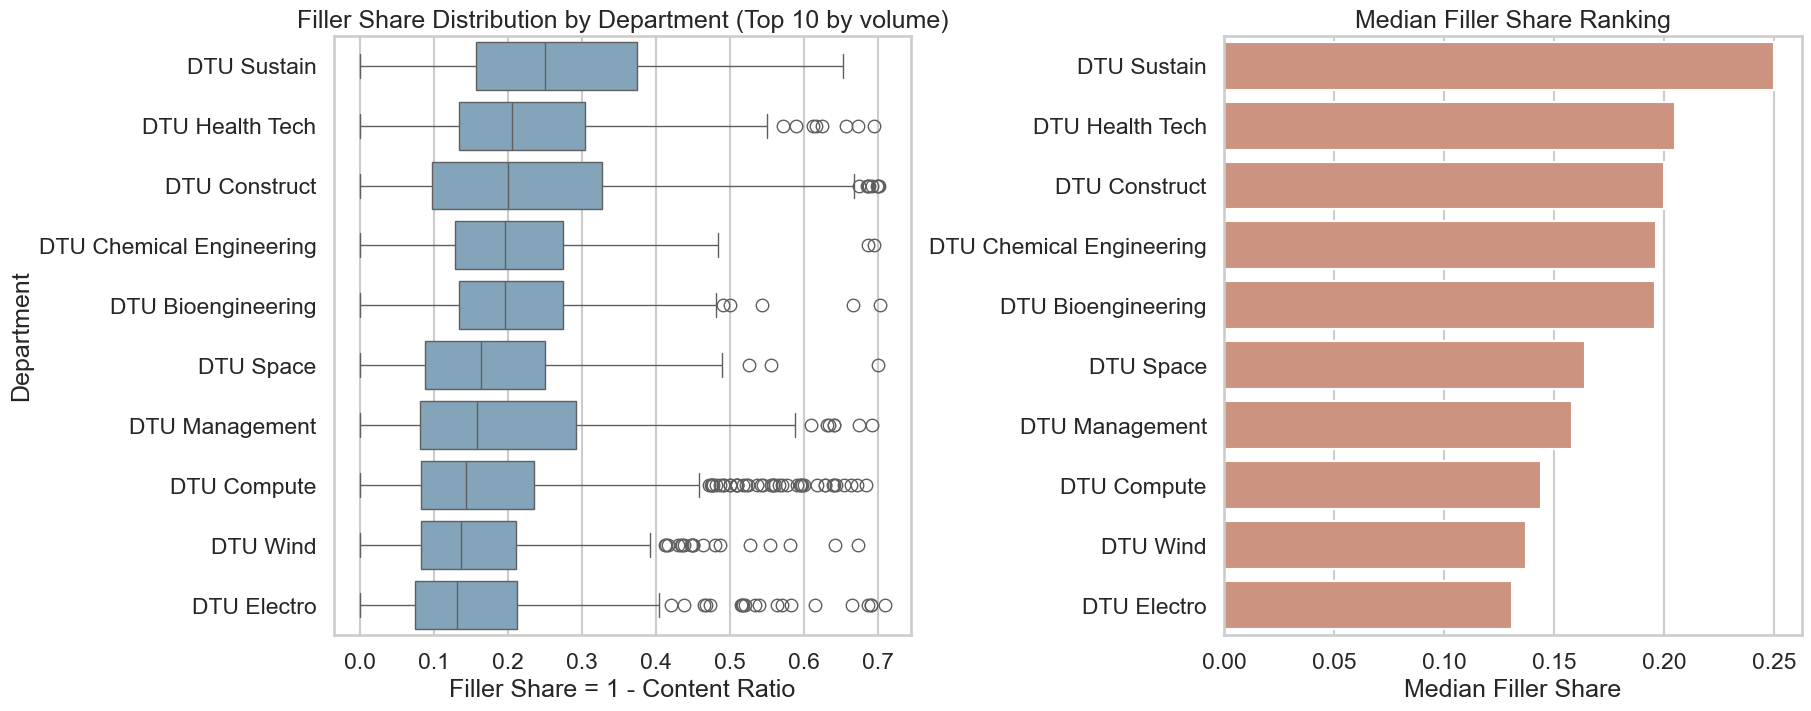

,Department_new,filler_share
8,DTU Sustain,0.250000
5,DTU Health Tech,0.205128
3,DTU Construct,0.200000
1,DTU Chemical Engineering,0.196429
0,DTU Bioengineering,0.195922
7,DTU Space,0.164179
6,DTU Management,0.157895
2,DTU Compute,0.144068
9,DTU Wind,0.137255
4,DTU Electro,0.130791


In [16]:
# 3A) The Content Ratio: core content vs non-core pages
dept_counts = analysis_df["Department_new"].value_counts()
top_departments = dept_counts.head(10).index
ratio_df = analysis_df[analysis_df["Department_new"].isin(top_departments)].copy()

dept_filler = (
    ratio_df.groupby("Department_new", as_index=False)["filler_share"]
    .median()
    .sort_values("filler_share", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
sns.boxplot(data=ratio_df, x="filler_share", y="Department_new", order=dept_filler["Department_new"], ax=axes[0], color="#7aa6c2")
axes[0].set_title("Filler Share Distribution by Department (Top 10 by volume)")
axes[0].set_xlabel("Filler Share = 1 - Content Ratio")
axes[0].set_ylabel("Department")

sns.barplot(data=dept_filler, x="filler_share", y="Department_new", ax=axes[1], color="#d98e73")
axes[1].set_title("Median Filler Share Ranking")
axes[1].set_xlabel("Median Filler Share")
axes[1].set_ylabel("")

plt.show()
display(dept_filler.head(10))

### Narrative Insight: Content Ratio

A higher filler share can indicate discipline-specific reporting norms (for example, extensive appendices, references, or supplementary methods). The spread within each department is as important as the median: wide boxplots suggest inconsistent thesis structure standards within the same field.

Years included in temporal plots (< 2026):


,Publication Year,thesis_count
0,2019,354
1,2020,482
2,2021,525
3,2022,540
4,2023,786
5,2024,741
6,2025,826


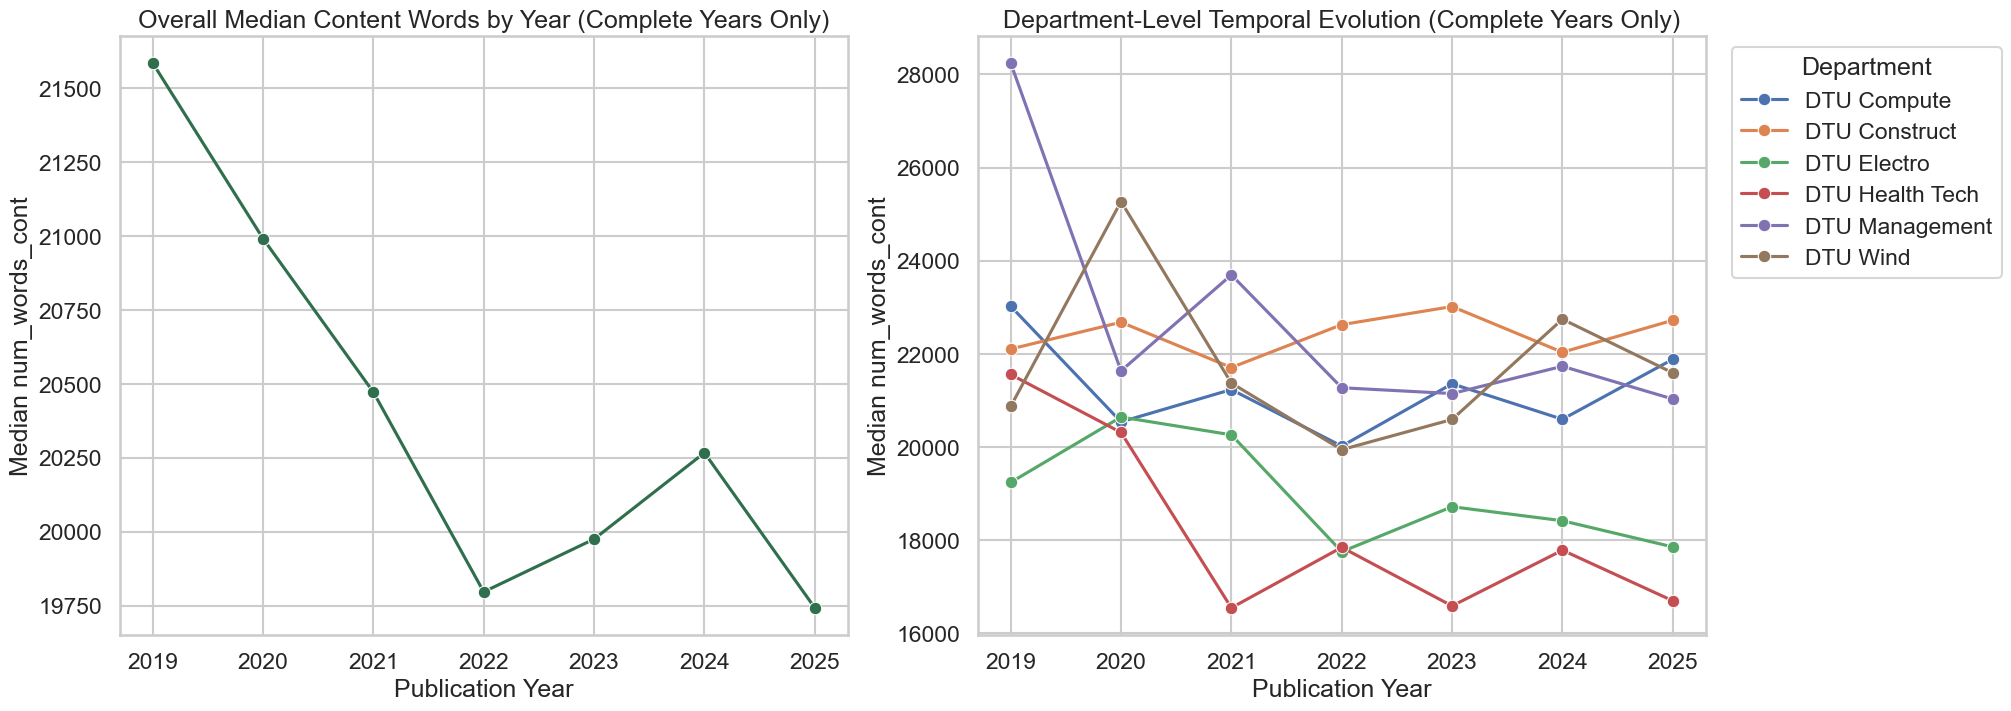

In [17]:
# 3B) Temporal evolution of thesis length
from datetime import datetime

# Exclude in-progress publication years (the current calendar year) to reduce partial-year skew
current_year = datetime.now().year
temporal_df = analysis_df[analysis_df["Publication Year"] < current_year].copy()

year_counts_temporal = (
    temporal_df["Publication Year"]
    .value_counts()
    .sort_index()
    .rename_axis("Publication Year")
    .reset_index(name="thesis_count")
)
print(f"Years included in temporal plots (< {current_year}):")
display(year_counts_temporal)

yearly_overall = (
    temporal_df.groupby("Publication Year", as_index=False)["num_words_cont"]
    .median()
    .sort_values("Publication Year")
)

top6_depts = temporal_df["Department_new"].value_counts().head(6).index
yearly_dept = (
    temporal_df[temporal_df["Department_new"].isin(top6_depts)]
    .groupby(["Publication Year", "Department_new"], as_index=False)["num_words_cont"]
    .median()
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)
sns.lineplot(data=yearly_overall, x="Publication Year", y="num_words_cont", marker="o", ax=axes[0], color="#2f6f4e")
axes[0].set_title("Overall Median Content Words by Year (Complete Years Only)")
axes[0].set_ylabel("Median num_words_cont")

sns.lineplot(data=yearly_dept, x="Publication Year", y="num_words_cont", hue="Department_new", marker="o", ax=axes[1])
axes[1].set_title("Department-Level Temporal Evolution (Complete Years Only)")
axes[1].set_ylabel("Median num_words_cont")
axes[1].legend(title="Department", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

### Narrative Insight: Temporal Evolution

The temporal view now uses **complete years only** by excluding the current calendar year, so partial-year thesis volumes do not distort medians or trend shape.

If department trend lines diverge over time, writing-length norms are likely becoming more field-specific. Parallel movement across lines suggests institution-wide shifts (for example, formatting policy changes or broader pedagogical trends).

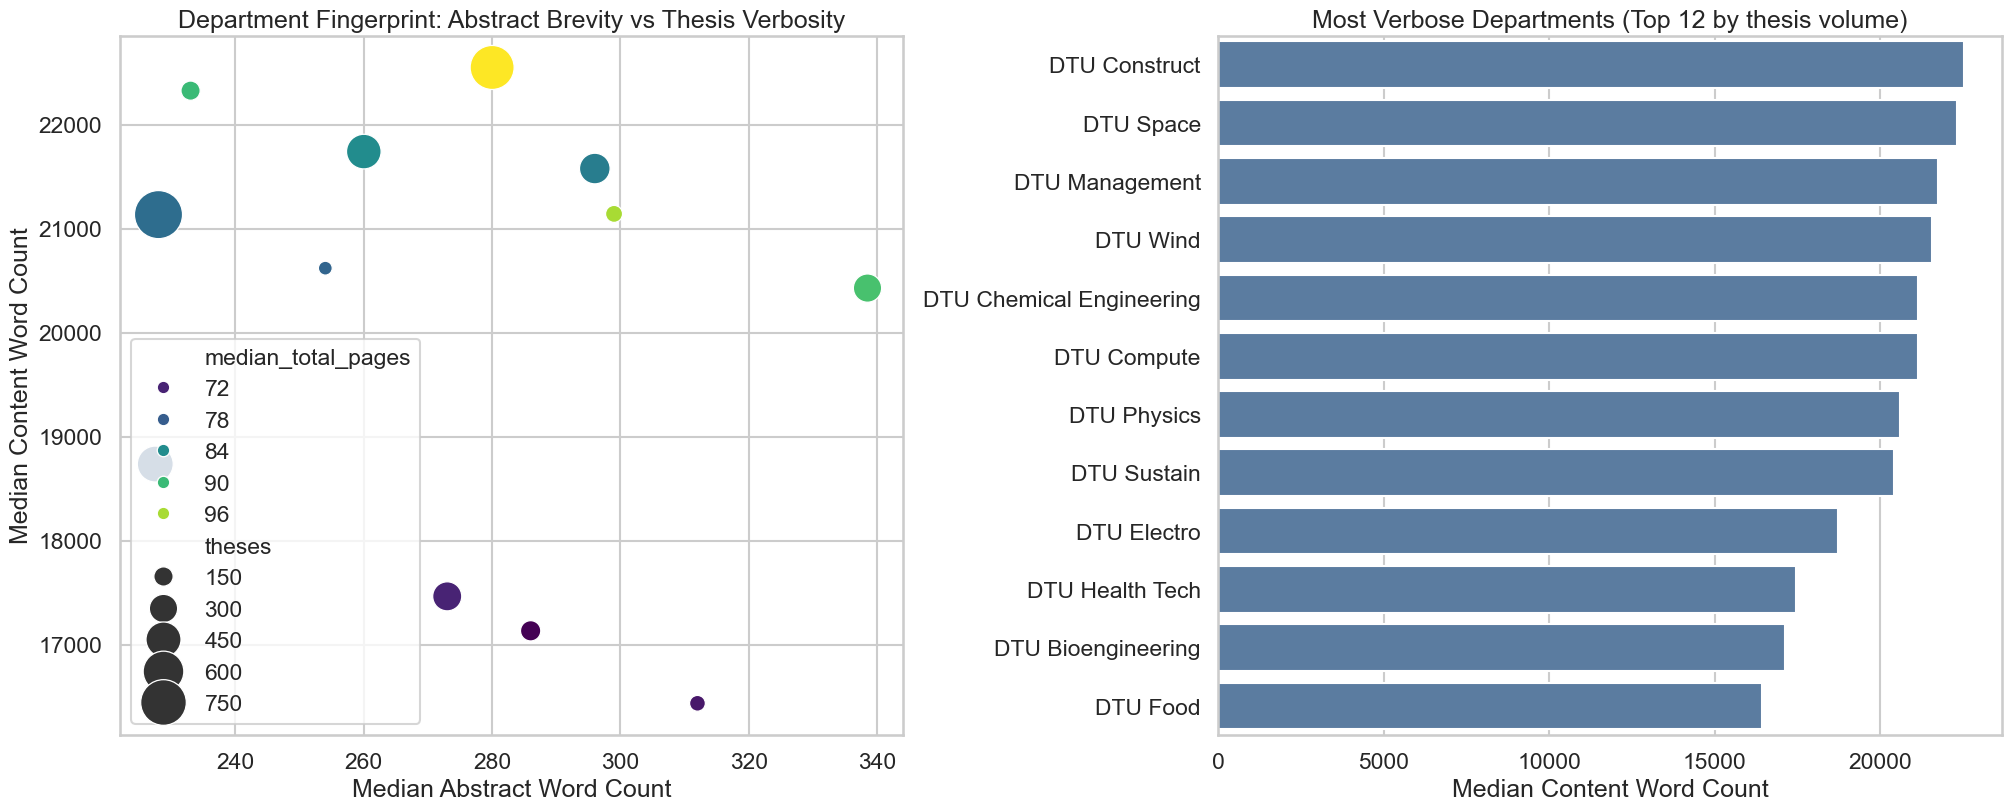

,Department_new,theses,median_content_words,median_total_pages,median_abstract_words
5,DTU Construct,699,22549.0,100.0,280.0
13,DTU Space,149,22326.0,90.0,233.0
11,DTU Management,440,21740.0,84.0,260.0
15,DTU Wind,349,21577.0,82.0,296.0
2,DTU Chemical Engineering,121,21141.0,96.0,299.0
4,DTU Compute,831,21134.0,80.0,228.0
12,DTU Physics,87,20619.0,79.0,254.0
14,DTU Sustain,300,20427.5,91.0,338.5
6,DTU Electro,472,18735.5,78.0,227.5
10,DTU Health Tech,316,17463.5,72.0,273.0


In [18]:
# 3C) Departmental fingerprinting
fingerprint = (
    analysis_df.groupby("Department_new", as_index=False)
    .agg(
        theses=("member_id_ss_metrics", "count"),
        median_content_words=("num_words_cont", "median"),
        median_total_pages=("num_tot_pages", "median"),
        median_abstract_words=("abstract_word_count", "median"),
    )
    .sort_values("theses", ascending=False)
)

fp_top = fingerprint.head(12).copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)
sns.scatterplot(
    data=fp_top,
    x="median_abstract_words",
    y="median_content_words",
    size="theses",
    hue="median_total_pages",
    palette="viridis",
    sizes=(100, 1200),
    ax=axes[0]
)
axes[0].set_title("Department Fingerprint: Abstract Brevity vs Thesis Verbosity")
axes[0].set_xlabel("Median Abstract Word Count")
axes[0].set_ylabel("Median Content Word Count")

verbose_rank = fp_top.sort_values("median_content_words", ascending=False)
sns.barplot(data=verbose_rank, x="median_content_words", y="Department_new", ax=axes[1], color="#4f7cac")
axes[1].set_title("Most Verbose Departments (Top 12 by thesis volume)")
axes[1].set_xlabel("Median Content Word Count")
axes[1].set_ylabel("")

plt.show()
display(fp_top.sort_values("median_content_words", ascending=False).head(12))

### Narrative Insight: Departmental Fingerprints

Departments with high content-word medians but short abstracts may prioritize technical depth over broad framing, while departments with longer abstracts may emphasize contextualization and research positioning. The fingerprint view highlights these disciplinary writing signatures.

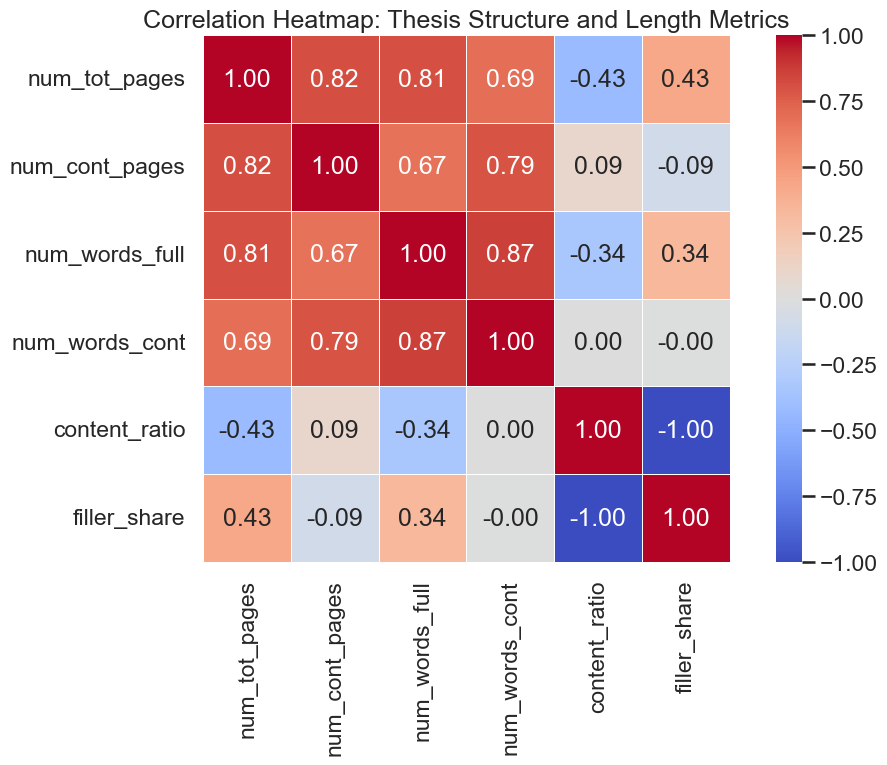

,num_tot_pages,num_cont_pages,num_words_full,num_words_cont,content_ratio,filler_share
num_tot_pages,1.00,0.82,0.81,0.69,-0.43,0.43
num_cont_pages,0.82,1.00,0.67,0.79,0.09,-0.09
num_words_full,0.81,0.67,1.00,0.87,-0.34,0.34
num_words_cont,0.69,0.79,0.87,1.00,0.00,-0.00
content_ratio,-0.43,0.09,-0.34,0.00,1.00,-1.00
filler_share,0.43,-0.09,0.34,-0.00,-1.00,1.00


In [19]:
# 3D) Correlation heatmap across structural and textual metrics
corr_cols = ["num_tot_pages", "num_cont_pages", "num_words_full", "num_words_cont", "abstract_word_count", "content_ratio", "filler_share"]
corr_df = analysis_df[corr_cols].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap: Thesis Structure and Length Metrics")
plt.tight_layout()
plt.show()

display(corr.round(2))

### Narrative Insight: Correlation Structure

Strong positive correlations between page and word metrics are expected. More interesting are weak links between abstract length and full thesis length, which may indicate that abstract style is governed more by disciplinary norms than by document size.

In [20]:
# 4) Anomaly detection: extreme theses by content words and filler share
high_words_cutoff = analysis_df["num_words_cont"].quantile(0.99)
high_filler_cutoff = analysis_df["filler_share"].quantile(0.99)

anomalies = analysis_df[
    (analysis_df["num_words_cont"] >= high_words_cutoff) |
    (analysis_df["filler_share"] >= high_filler_cutoff)
][[
    "Title", "Author", "Department_new", "Publication Year",
    "num_words_cont", "num_tot_pages", "num_cont_pages", "filler_share"
]].sort_values(["num_words_cont", "filler_share"], ascending=False)

print(f"Anomalies found: {len(anomalies)}")
display(anomalies.head(20))

Anomalies found: 86


,Title,Author,Department_new,Publication Year,num_words_cont,num_tot_pages,num_cont_pages,filler_share
681,Methane emissions from dairy and pig farms in ...,"Jensen, Nina Strøyer",DTU Sustain,2020,180529,109,101,0.073394
2114,Studying mixing processes in stars using TESS ...,"Pedros, Oliver Dürfeldt",DTU Space,2023,147132,436,436,0.000000
2731,Foundations without concrete in Danish buildin...,"Grunnan, Mads Dalsgaard",DTU Construct,2024,110324,531,426,0.197740
2840,Reuse of building components: A case study on ...,"Kjeldsen, Ann Sofie Grube",DTU Sustain,2024,105117,378,378,0.000000
1566,Improved Vortex Induced Vibrations (VIV) Pred...,"Farantos, Christos",DTU Construct,2022,96417,360,195,0.458333
2548,Investigation of settlement of masts of a powe...,"Ville, Tom De",DTU Sustain,2023,88215,253,222,0.122530
4023,Detailed design and development of Gnist Educa...,"Møller, Sidsel Lindved|Svanebjerg, Andreas Ihm...",DTU Construct,2025,84631,209,198,0.052632
264,Development of a new parametric tool and asses...,"Gkouvelou, Eleni|Moskoveli, Dimitra Alexandros",DTU Construct,2019,79277,249,210,0.156627
1425,Dual Fish Eye Camera Video Stitcher using an F...,"Palani, Kishan Suchet",DTU Compute,2022,77244,220,218,0.009091
580,The Development and Use of Backcasting as Meth...,"Kade, Oliver Howard|Lenz, Matthias",DTU Sustain,2020,76304,194,159,0.180412


## 5) Final Narrative Synthesis

This dataset reveals that thesis writing is not a single institutional style but a constellation of disciplinary conventions.

Key takeaways:
- **Structure varies by department**: filler share distributions suggest different expectations for appendices and references.
- **Length evolves over time**: median trends indicate whether thesis bodies are expanding or stabilizing.
- **Departmental fingerprints are distinct**: abstract behavior and body verbosity do not always move together.
- **Correlations reveal design logic**: pages and words scale together, while abstract length can remain comparatively independent.

For publication, these plots can be exported as high-resolution figures and accompanied by department-level significance testing (for example, Kruskal-Wallis across departments).

# EXPLORING SEASONALITY

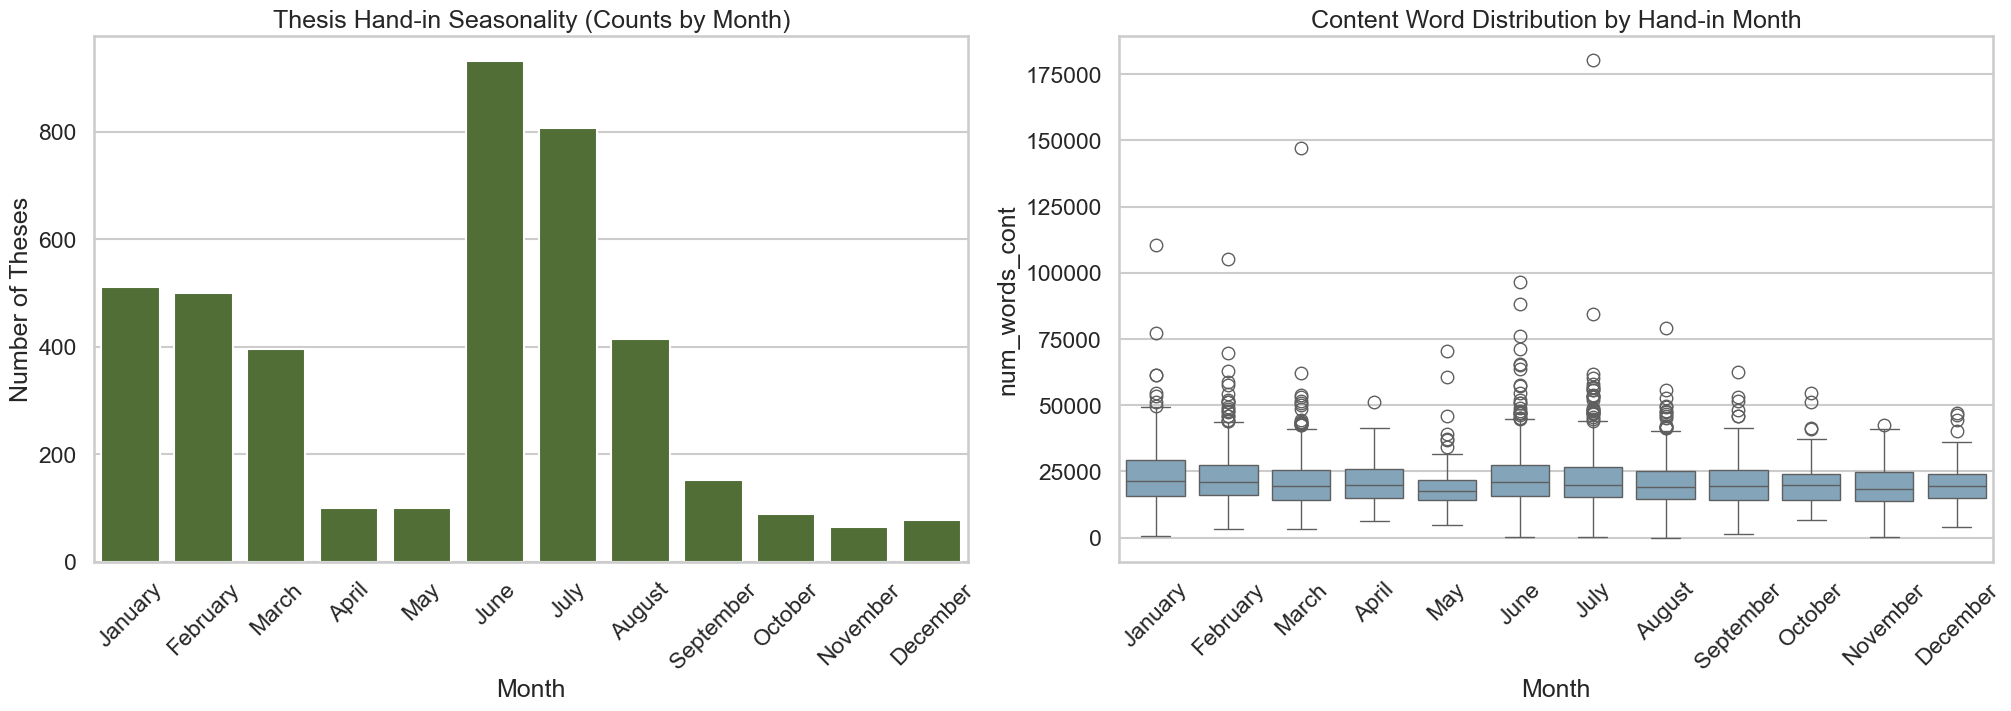

,month,thesis_count,share_pct
0,January,511,12.34
1,February,500,12.07
2,March,396,9.56
3,April,100,2.41
4,May,99,2.39
5,June,932,22.50
6,July,807,19.48
7,August,415,10.02
8,September,152,3.67
9,October,88,2.12


Rows with unparseable/missing handin_month: 112


In [23]:
# Seasonality (month-only): ignore year and inspect hand-in month distribution
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

season_df = analysis_df.copy()
season_df["handin_month_dt"] = pd.to_datetime(season_df["handin_month"], format="%B %Y", errors="coerce")
season_df["month_name"] = season_df["handin_month_dt"].dt.month_name()

month_counts = season_df["month_name"].value_counts().reindex(month_order, fill_value=0)
month_share = (month_counts / month_counts.sum() * 100).round(2)

month_summary = pd.DataFrame({
    "month": month_order,
    "thesis_count": month_counts.values,
    "share_pct": month_share.values
})

fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)

sns.barplot(data=month_summary, x="month", y="thesis_count", ax=axes[0], color="#4f772d")
axes[0].set_title("Thesis Hand-in Seasonality (Counts by Month)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Theses")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=season_df.dropna(subset=["month_name"]),
    x="month_name", y="num_words_cont",
    order=month_order, ax=axes[1], color="#7aa6c2"
)
axes[1].set_title("Content Word Distribution by Hand-in Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("num_words_cont")
axes[1].tick_params(axis="x", rotation=45)

plt.show()

display(month_summary)
print(f"Rows with unparseable/missing handin_month: {season_df['month_name'].isna().sum()}")